# Sales EDA Notebook:
### This notebook explores the sales dataset to understand general patterns and trends. We use visualizations to see how sales change over time, which products perform well, and what factors may affect sales. Each chart is followed by a short insight to explain the main idea in a simple way.
# Importing libraries:

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
plt.style.use("default")

#  Data Loading and Inspection
#### Load Sales dataset and display basic information to understand the structure and data types, as well as summary statistics to get an overview of the data.

In [5]:
df = pd.read_csv(r"D:\Student Actevities\IEEE S2\sales\b5972e0e-a5b3-4ce8-b650-6da919808343.csv")
df.head()

,date,sales,ad_spend,visitors,conversion_rate,product_category,rating,returns,country
0,2024-01-01,2185,124.84,2060,0.0378,Clothing,3.2,0,Morocco
1,2024-01-02,2382,94.89,1870,0.0245,Electronics,3.7,0,Saudi Arabia
2,2024-01-03,1720,135.99,1524,0.0218,Clothing,4.0,0,Saudi Arabia
3,2024-01-04,2113,181.56,1241,0.0300,Electronics,3.2,0,Egypt
4,2024-01-05,1870,95.51,1779,0.0283,Beauty,3.5,0,Saudi Arabia


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(500, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              500 non-null    object 
 1   sales             500 non-null    int64  
 2   ad_spend          500 non-null    float64
 3   visitors          500 non-null    int64  
 4   conversion_rate   500 non-null    float64
 5   product_category  500 non-null    object 
 6   rating            500 non-null    float64
 7   returns           500 non-null    int64  
 8   country           500 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 35.3+ KB


In [9]:
df.describe()

,sales,ad_spend,visitors,conversion_rate,rating,returns
count,500.0000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,2006.3660,550.341860,1543.402000,0.030362,4.08700,0.040000
std,195.5918,266.216347,404.089209,0.009757,0.55087,0.196155
min,1461.0000,27.780000,341.000000,0.005000,2.50000,0.000000
25%,1881.2500,309.820000,1258.750000,0.023900,3.70000,0.000000
50%,2006.0000,546.060000,1548.000000,0.029950,4.10000,0.000000
75%,2130.2500,769.287500,1801.750000,0.037025,4.50000,0.000000
max,2526.0000,1116.070000,2541.000000,0.061900,5.00000,1.000000


In [10]:
df.describe(include='O')

,date,product_category,country
count,500,500,500
unique,500,5,5
top,2025-05-14,Clothing,Egypt
freq,1,132,197


_________________________________________________________________________________
# Exploratory Data Analysis (EDA)

In [14]:
df['net_revenue'] = df['sales'] - df['ad_spend']

In [12]:
df.head()

,date,sales,ad_spend,visitors,conversion_rate,product_category,rating,returns,country,net_revenue
0,2024-01-01,2185,124.84,2060,0.0378,Clothing,3.2,0,Morocco,2060.16
1,2024-01-02,2382,94.89,1870,0.0245,Electronics,3.7,0,Saudi Arabia,2287.11
2,2024-01-03,1720,135.99,1524,0.0218,Clothing,4.0,0,Saudi Arabia,1584.01
3,2024-01-04,2113,181.56,1241,0.0300,Electronics,3.2,0,Egypt,1931.44
4,2024-01-05,1870,95.51,1779,0.0283,Beauty,3.5,0,Saudi Arabia,1774.49


 Numerical columns: ['sales', 'ad_spend', 'visitors', 'conversion_rate', 'rating', 'net_revenue']
 Categorical columns: ['product_category', 'country']
 NUMERICAL ANALYSIS

 SALES
Mean: 2006.37
Median: 2006.00
Min/Max: 1461.00 / 2526.00


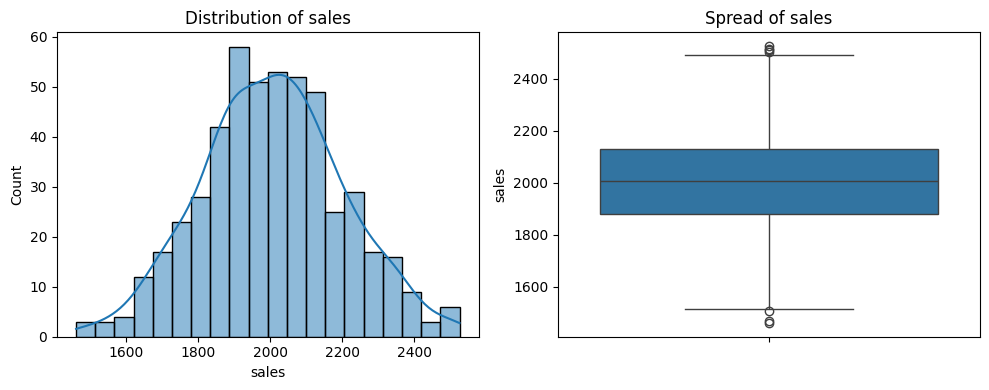


 AD_SPEND
Mean: 550.34
Median: 546.06
Min/Max: 27.78 / 1116.07


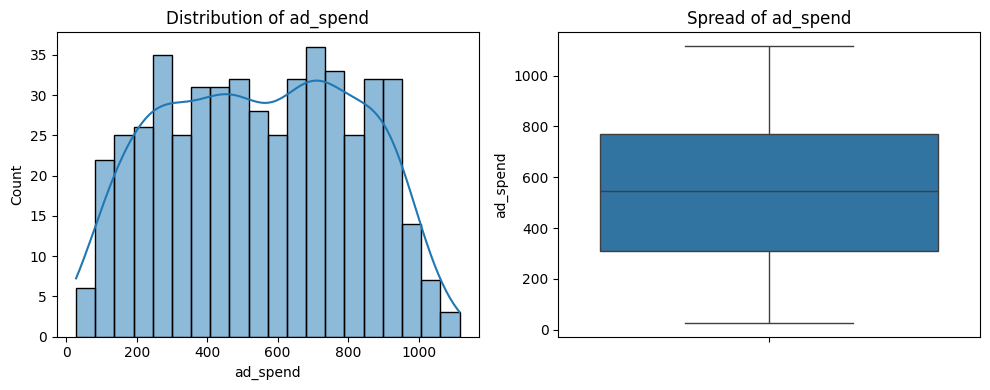


 VISITORS
Mean: 1543.40
Median: 1548.00
Min/Max: 341.00 / 2541.00


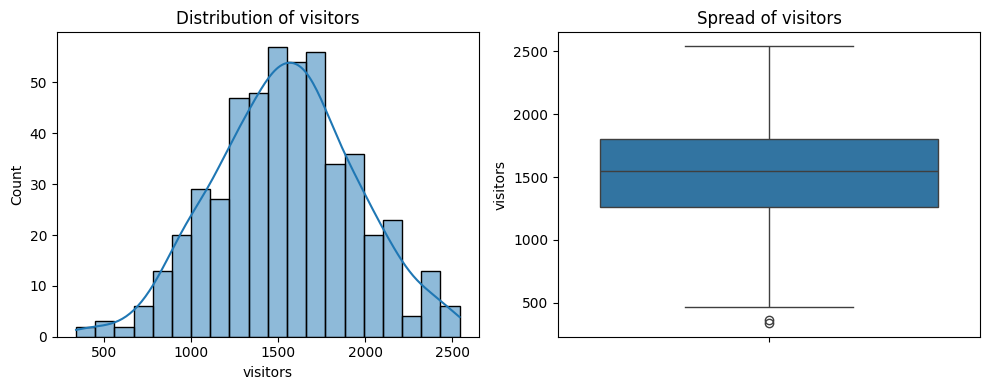


 CONVERSION_RATE
Mean: 0.03
Median: 0.03
Min/Max: 0.01 / 0.06


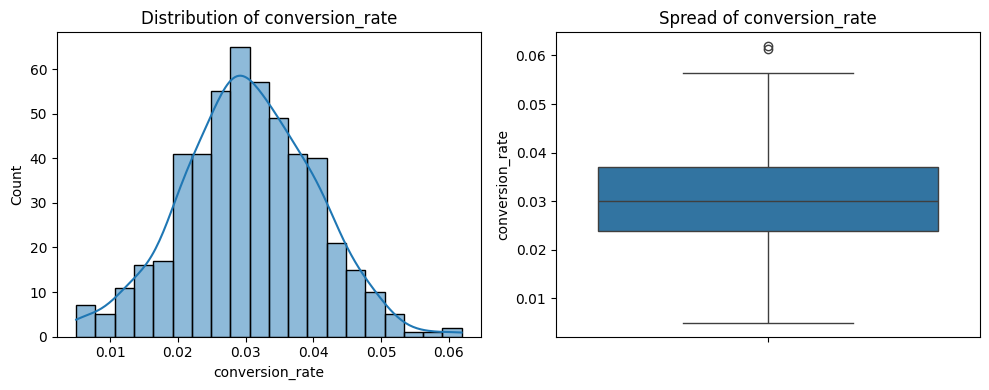


 RATING
Mean: 4.09
Median: 4.10
Min/Max: 2.50 / 5.00


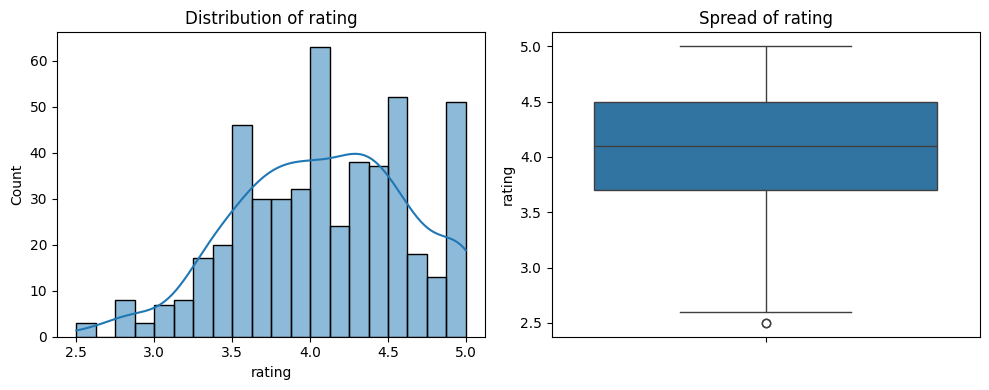


 NET_REVENUE
Mean: 1456.02
Median: 1454.03
Min/Max: 532.43 / 2287.11


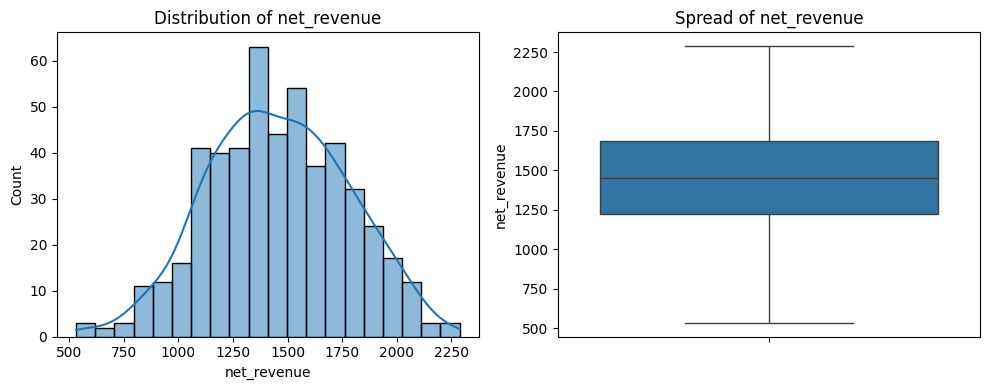


 CATEGORICAL ANALYSIS

 PRODUCT_CATEGORY
Top categories:
product_category
Clothing       132
Electronics    121
Beauty          88
Home            88
Sports          71
Name: count, dtype: int64


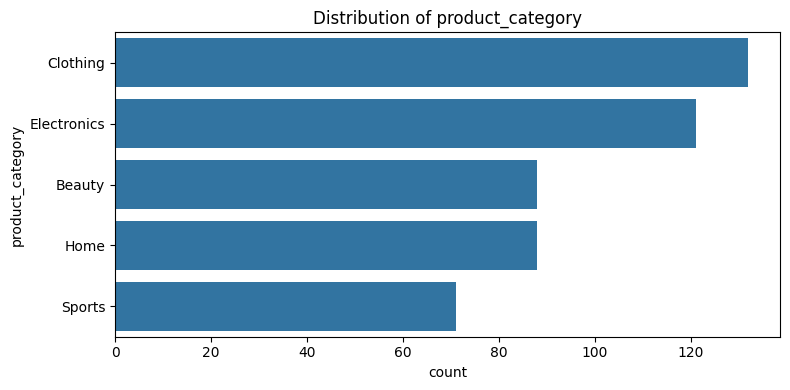


 COUNTRY
Top categories:
country
Egypt           197
Saudi Arabia    117
UAE              92
Jordan           50
Morocco          44
Name: count, dtype: int64


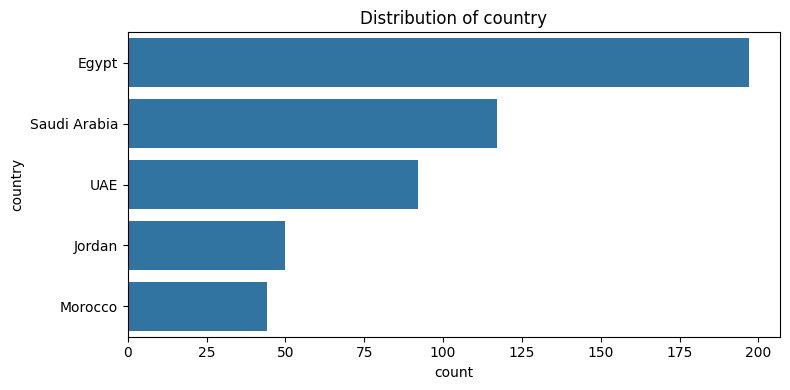

 Numerical columns: ['sales', 'ad_spend', 'visitors', 'conversion_rate', 'rating', 'net_revenue']
 Categorical columns: ['product_category', 'country']


In [16]:
df['net_revenue'] = df['sales'] - df['ad_spend']

num_cols = ['sales', 'ad_spend', 'visitors', 'conversion_rate', 'rating', 'net_revenue']
cat_cols = ['product_category', 'country']

print(f" Numerical columns: {num_cols}")
print(f" Categorical columns: {cat_cols}")
def univ_explore_num(df, col):
    print(f"\n{'='*40}")
    print(f" {col.upper()}")
    print(f"{'='*40}")
    
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Min/Max: {df[col].min():.2f} / {df[col].max():.2f}")
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Spread of {col}')
    
    plt.tight_layout()
    plt.show()

print(" NUMERICAL ANALYSIS")
for col in num_cols:
    univ_explore_num(df, col)

print("\n CATEGORICAL ANALYSIS")  
for col in cat_cols:
    univ_explore_cat(df, col)
df['net_revenue'] = df['sales'] - df['ad_spend']

num_cols = ['sales', 'ad_spend', 'visitors', 'conversion_rate', 'rating', 'net_revenue']
cat_cols = ['product_category', 'country']

print(f" Numerical columns: {num_cols}")
print(f" Categorical columns: {cat_cols}")

## Correlation Heatmap:

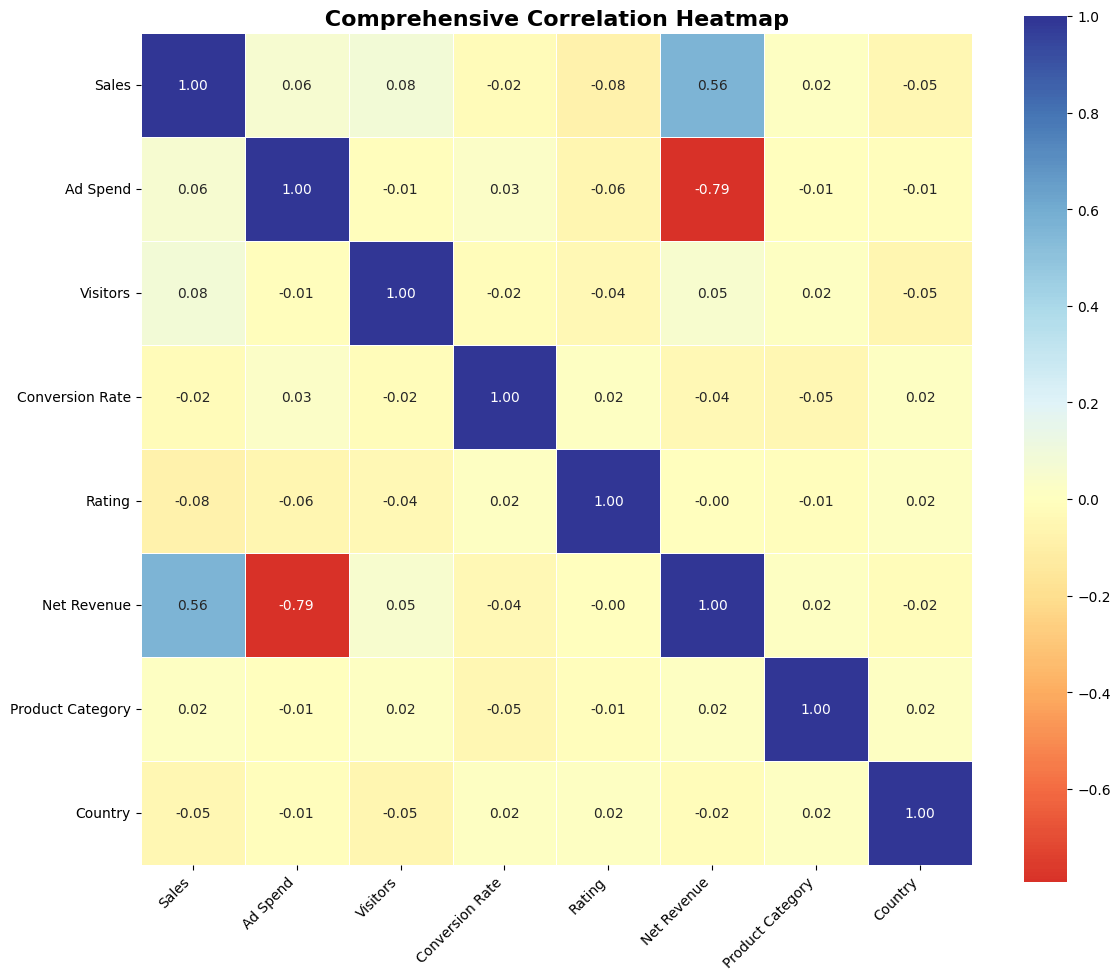

In [18]:
df_encoded = df.copy()

df_encoded['product_category_encoded'] = df_encoded['product_category'].astype('category').cat.codes
df_encoded['country_encoded'] = df_encoded['country'].astype('category').cat.codes

all_columns = ['sales', 'ad_spend', 'visitors', 'conversion_rate', 'rating', 'net_revenue', 
              'product_category_encoded', 'country_encoded']

correlation_matrix = df_encoded[all_columns].corr()

display_columns = ['Sales', 'Ad Spend', 'Visitors', 'Conversion Rate', 'Rating', 'Net Revenue', 
                  'Product Category', 'Country']

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdYlBu', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            xticklabels=display_columns,
            yticklabels=display_columns)

plt.title(' Comprehensive Correlation Heatmap ', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Sales vs Ad Spend

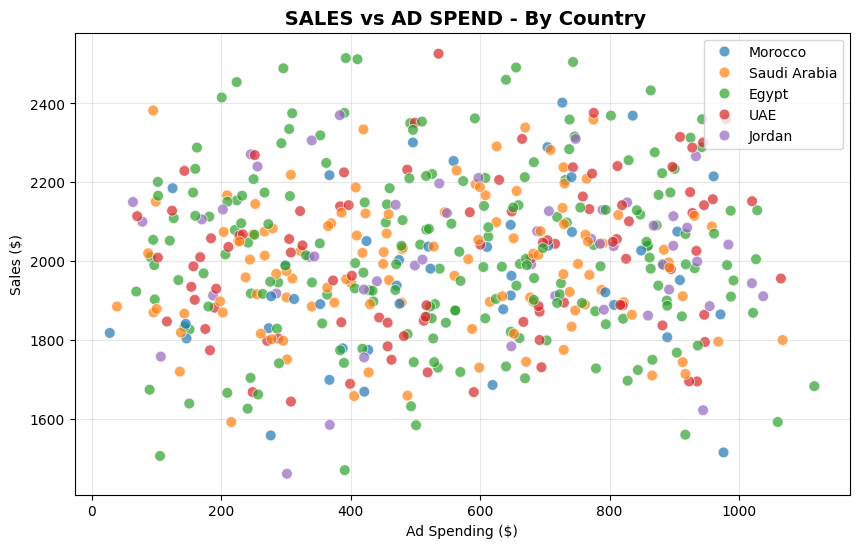

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ad_spend', y='sales', hue='country', alpha=0.7, s=60)
plt.title(' SALES vs AD SPEND - By Country', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spending ($)')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Sales vs Visitors

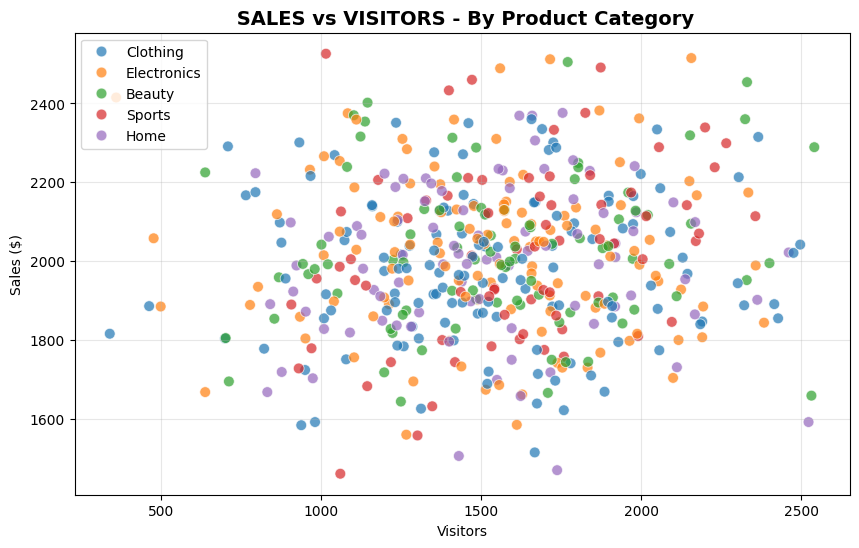

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='visitors', y='sales', hue='product_category', alpha=0.7, s=60)
plt.title(' SALES vs VISITORS - By Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Visitors')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Sales vs Conversion Rate

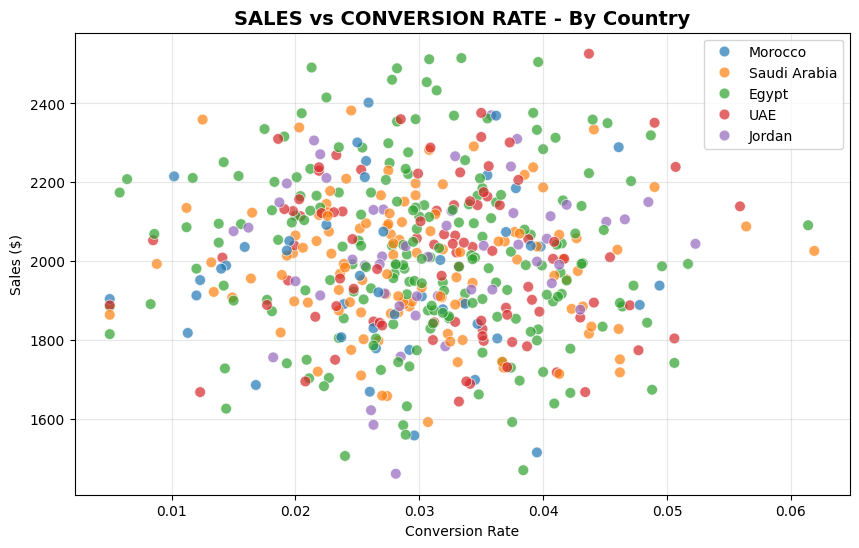

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='conversion_rate', y='sales', hue='country', alpha=0.7, s=60)
plt.title('SALES vs CONVERSION RATE - By Country', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Rate')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Sales vs Product Category

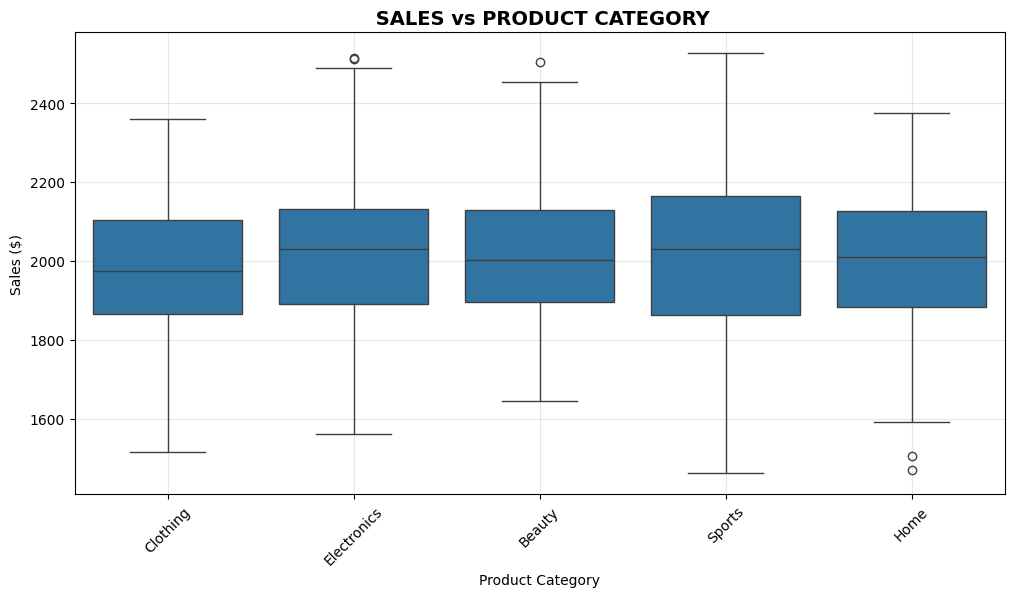

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='product_category', y='sales')
plt.title(' SALES vs PRODUCT CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## Sales vs Country

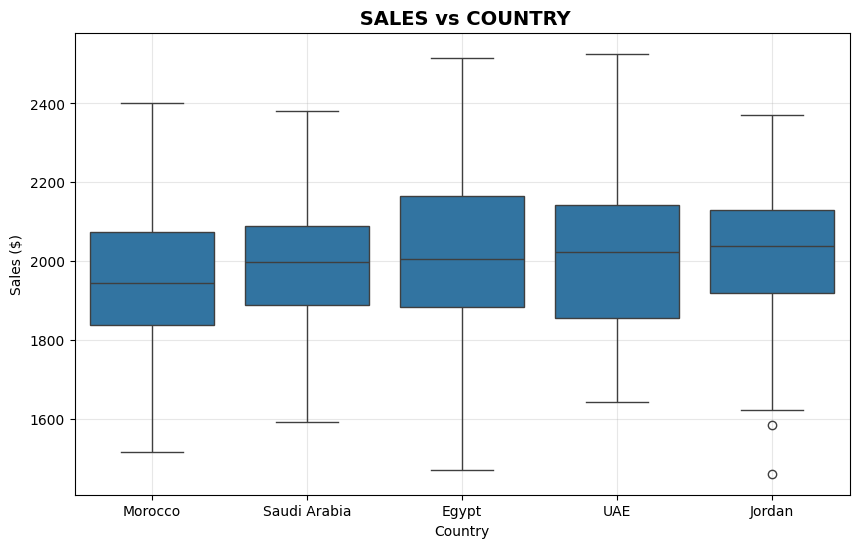

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='country', y='sales')
plt.title(' SALES vs COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

## Sales Trend Over Time

C:\Users\DT\AppData\Local\Temp\ipykernel_28864\1065727193.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\DT\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


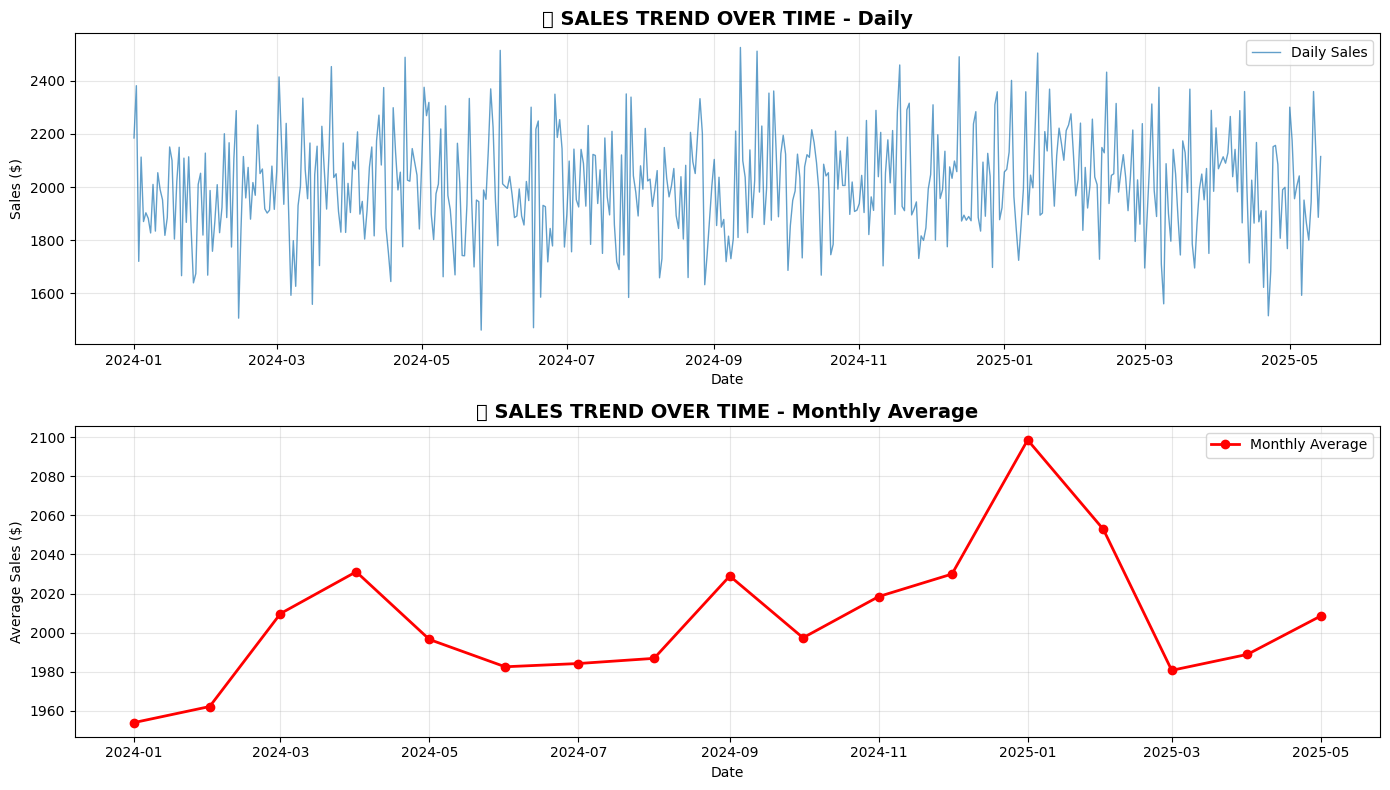

In [ ]:
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(df['date'], df['sales'], alpha=0.7, linewidth=1, label='Daily Sales')
plt.title('SALES TREND OVER TIME - Daily', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['sales'].mean()
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.plot(monthly_sales.index, monthly_sales.values, linewidth=2, color='red', marker='o', label='Monthly Average')
plt.title('SALES TREND OVER TIME - Monthly Average', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Sales ($)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Top Countries by Sales & Their Product Preferences

C:\Users\DT\AppData\Local\Temp\ipykernel_28864\503115980.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')


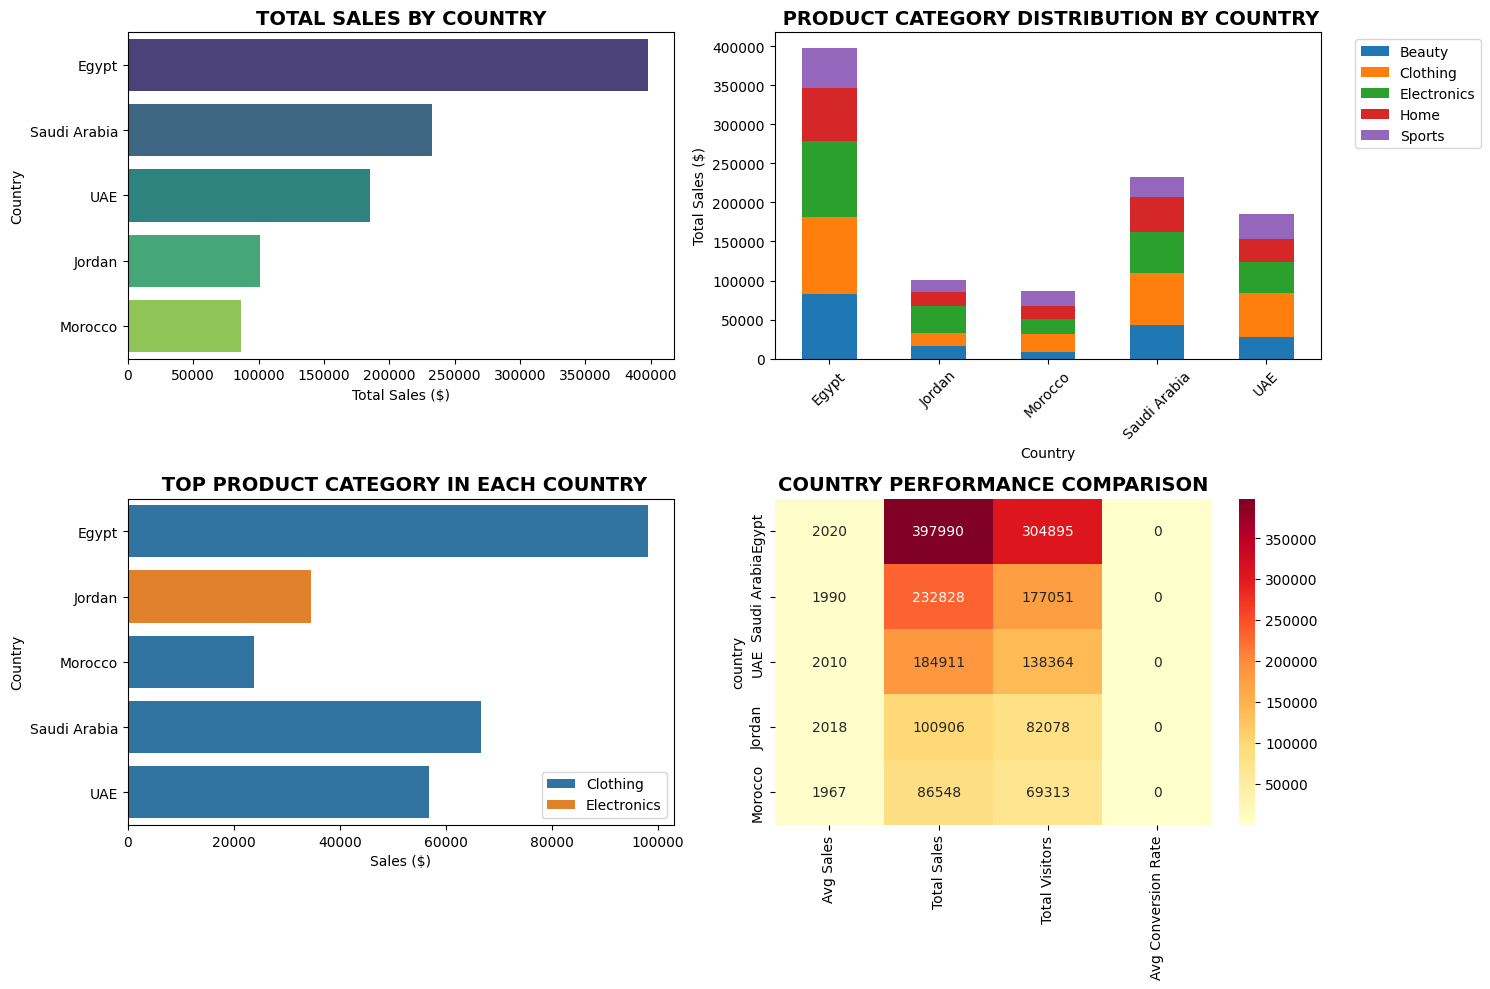

 DETAILED COUNTRY ANALYSIS:

🇺🇳 Egypt:
   Total Sales: $397,990
   Top Category: Clothing ($98,207)
   Avg Conversion Rate: 0.030

🇺🇳 Saudi Arabia:
   Total Sales: $232,828
   Top Category: Clothing ($66,686)
   Avg Conversion Rate: 0.030

🇺🇳 UAE:
   Total Sales: $184,911
   Top Category: Clothing ($56,759)
   Avg Conversion Rate: 0.032

🇺🇳 Jordan:
   Total Sales: $100,906
   Top Category: Electronics ($34,582)
   Avg Conversion Rate: 0.031

🇺🇳 Morocco:
   Total Sales: $86,548
   Top Category: Clothing ($23,852)
   Avg Conversion Rate: 0.027


In [29]:
country_sales = df.groupby('country')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')
plt.title('TOTAL SALES BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Country')

plt.subplot(2, 2, 2)
country_category = df.groupby(['country', 'product_category'])['sales'].sum().unstack()
country_category.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title(' PRODUCT CATEGORY DISTRIBUTION BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Sales ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
top_category_by_country = df.groupby(['country', 'product_category'])['sales'].sum().groupby('country').idxmax()
top_categories = [cat[1] for cat in top_category_by_country]
top_sales = [df.groupby(['country', 'product_category'])['sales'].sum()[cat] for cat in top_category_by_country]

sns.barplot(x=top_sales, y=top_category_by_country.index, hue=top_categories, dodge=False)
plt.title(' TOP PRODUCT CATEGORY IN EACH COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Country')

plt.subplot(2, 2, 4)
country_stats = df.groupby('country').agg({
    'sales': ['mean', 'sum'],
    'visitors': 'sum',
    'conversion_rate': 'mean'
}).round(2)

country_stats.columns = ['Avg Sales', 'Total Sales', 'Total Visitors', 'Avg Conversion Rate']
country_stats = country_stats.sort_values('Total Sales', ascending=False)

sns.heatmap(country_stats, annot=True, cmap='YlOrRd', fmt='.0f')
plt.title('COUNTRY PERFORMANCE COMPARISON', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(" DETAILED COUNTRY ANALYSIS:")
for country in country_sales.index:
    country_data = df[df['country'] == country]
    top_cat = country_data.groupby('product_category')['sales'].sum().idxmax()
    top_cat_sales = country_data.groupby('product_category')['sales'].sum().max()
    avg_conversion = country_data['conversion_rate'].mean()
    
    print(f"\n🇺🇳 {country}:")
    print(f"   Total Sales: ${country_sales[country]:,.0f}")
    print(f"   Top Category: {top_cat} (${top_cat_sales:,.0f})")
    print(f"   Avg Conversion Rate: {avg_conversion:.3f}")


## Ad Spend Impact on Sales by Country

C:\Users\DT\AppData\Local\Temp\ipykernel_28864\3043324971.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations, y=countries, palette='coolwarm')
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\3043324971.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roi_by_country = df.groupby('country').apply(lambda x: x['sales'].sum() / x['ad_spend'].sum()).sort_values(ascending=False)
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\3043324971.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

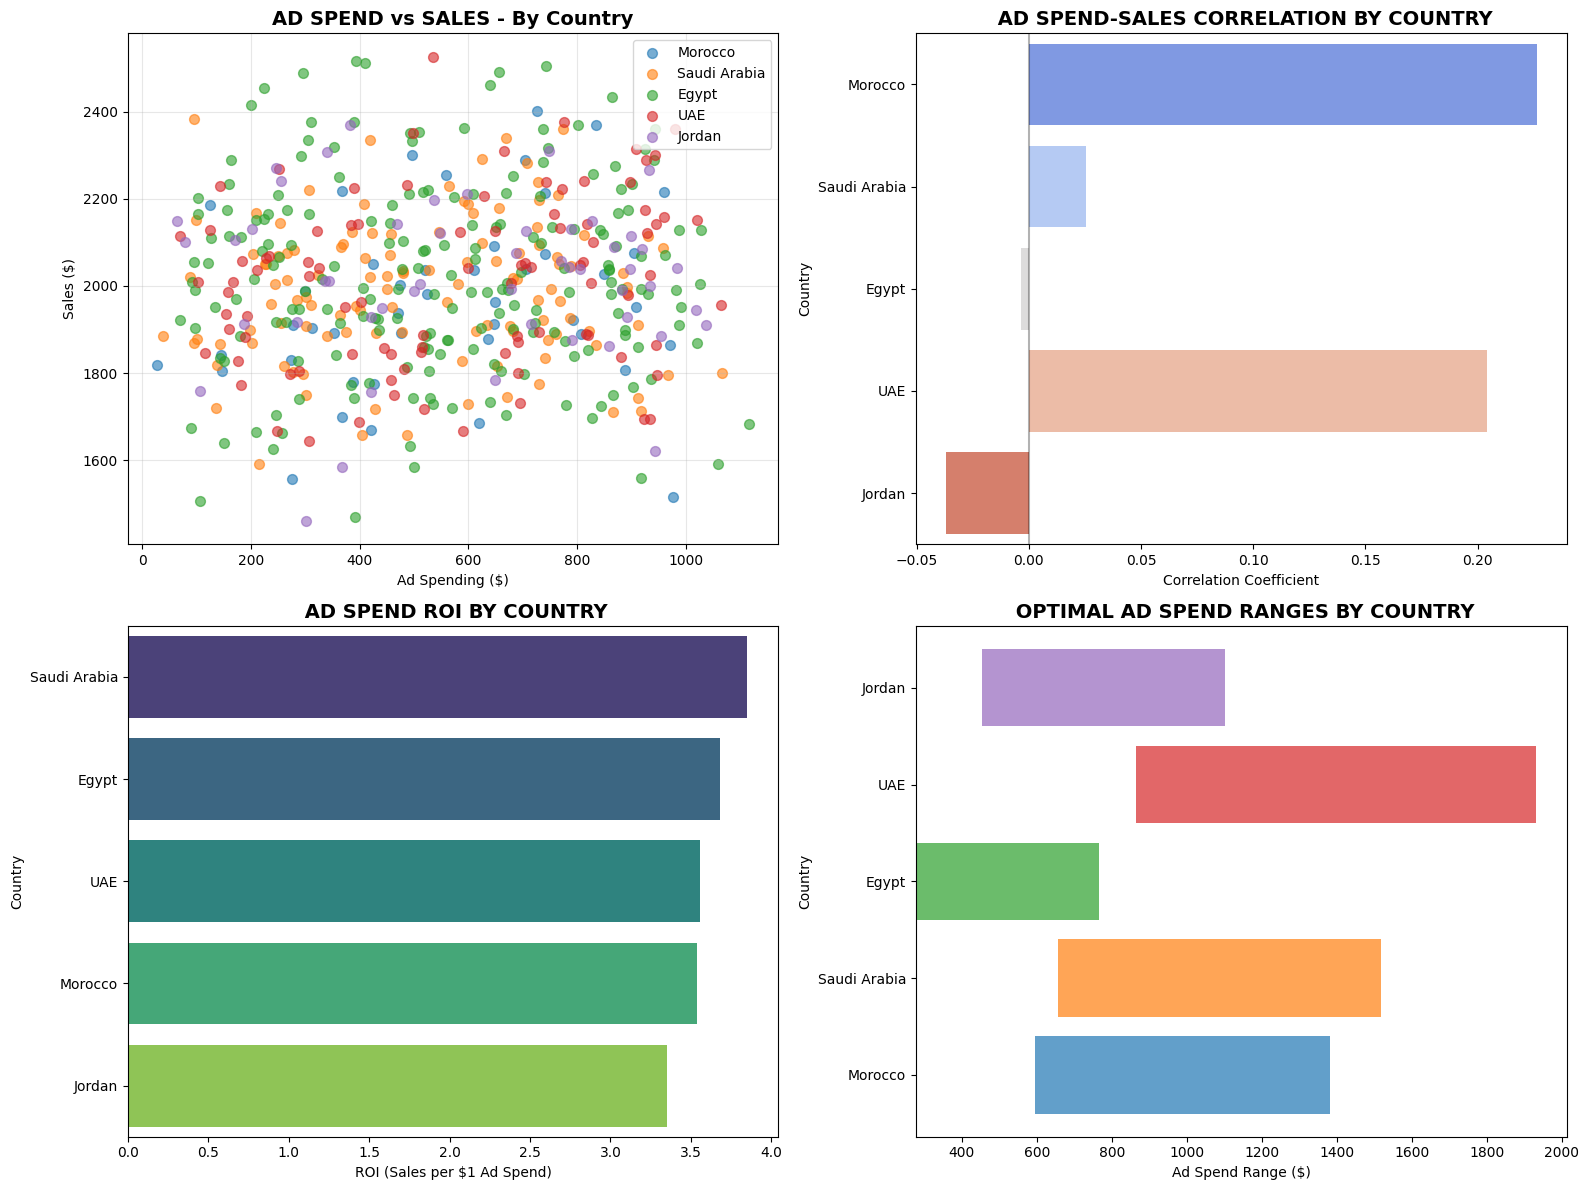

 DETAILED AD SPEND IMPACT ANALYSIS:

🇺🇳 Morocco:
    Correlation: 0.227
    ROI: $3.54 sales per $1 ad spend
    Avg Ad Spend: $556
    Avg Sales: $1967
 Effectiveness: MODERATE

🇺🇳 Saudi Arabia:
    Correlation: 0.025
    ROI: $3.85 sales per $1 ad spend
    Avg Ad Spend: $517
    Avg Sales: $1990
 Effectiveness: LOW

🇺🇳 Egypt:
    Correlation: -0.003
    ROI: $3.68 sales per $1 ad spend
    Avg Ad Spend: $549
    Avg Sales: $2020
 Effectiveness: LOW

🇺🇳 UAE:
    Correlation: 0.204
    ROI: $3.55 sales per $1 ad spend
    Avg Ad Spend: $566
    Avg Sales: $2010
 Effectiveness: MODERATE

🇺🇳 Jordan:
    Correlation: -0.037
    ROI: $3.35 sales per $1 ad spend
    Avg Ad Spend: $602
    Avg Sales: $2018
 Effectiveness: LOW

 HIGHEST IMPACT COUNTRY: Morocco
   Correlation: 0.227


In [31]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    plt.scatter(country_data['ad_spend'], country_data['sales'], alpha=0.6, label=country, s=50)
    
plt.title('AD SPEND vs SALES - By Country', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spending ($)')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
correlations = []
countries = []
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    corr = country_data['ad_spend'].corr(country_data['sales'])
    correlations.append(corr)
    countries.append(country)

sns.barplot(x=correlations, y=countries, palette='coolwarm')
plt.title(' AD SPEND-SALES CORRELATION BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Country')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.subplot(2, 2, 3)
roi_by_country = df.groupby('country').apply(lambda x: x['sales'].sum() / x['ad_spend'].sum()).sort_values(ascending=False)
sns.barplot(x=roi_by_country.values, y=roi_by_country.index, palette='viridis')
plt.title(' AD SPEND ROI BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('ROI (Sales per $1 Ad Spend)')
plt.ylabel('Country')

plt.subplot(2, 2, 4)
optimal_ranges = {}
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    bins = pd.cut(country_data['ad_spend'], bins=5)
    optimal_range = country_data.groupby(bins)['sales'].mean().idxmax()
    optimal_ranges[country] = optimal_range
    
    plt.barh(country, optimal_range.right, left=optimal_range.left, alpha=0.7, label=country)

plt.title(' OPTIMAL AD SPEND RANGES BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Ad Spend Range ($)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

print(" DETAILED AD SPEND IMPACT ANALYSIS:")
print("="*50)

for country in df['country'].unique():
    country_data = df[df['country'] == country]
    corr = country_data['ad_spend'].corr(country_data['sales'])
    roi = country_data['sales'].sum() / country_data['ad_spend'].sum()
    avg_ad_spend = country_data['ad_spend'].mean()
    avg_sales = country_data['sales'].mean()
    
    print(f"\n🇺🇳 {country}:")
    print(f"    Correlation: {corr:.3f}")
    print(f"    ROI: ${roi:.2f} sales per $1 ad spend")
    print(f"    Avg Ad Spend: ${avg_ad_spend:.0f}")
    print(f"    Avg Sales: ${avg_sales:.0f}")
    
    # Effectiveness rating
    if corr > 0.5 and roi > 5:
        effectiveness = "VERY HIGH"
    elif corr > 0.3 and roi > 4:
        effectiveness = "HIGH"
    elif corr > 0.1 and roi > 3:
        effectiveness = "MODERATE"
    else:
        effectiveness = "LOW"
    
    print(f" Effectiveness: {effectiveness}")

# Find best performing country
best_country = max(df['country'].unique(), 
                   key=lambda x: df[df['country'] == x]['ad_spend'].corr(df[df['country'] == x]['sales']))
best_corr = df[df['country'] == best_country]['ad_spend'].corr(df[df['country'] == best_country]['sales'])

print(f"\n HIGHEST IMPACT COUNTRY: {best_country}")
print(f"   Correlation: {best_corr:.3f}")

## Seasonal, Holiday & Monthly Sales Patterns

C:\Users\DT\AppData\Local\Temp\ipykernel_28864\326043722.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal_sales.index, y=seasonal_sales.values, palette='coolwarm')
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\326043722.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=holiday_sales.values, y=holiday_sales.index, palette='viridis')
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\326043722.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=holiday_conversion.values, y=holiday_conversion.index, palette='magma')


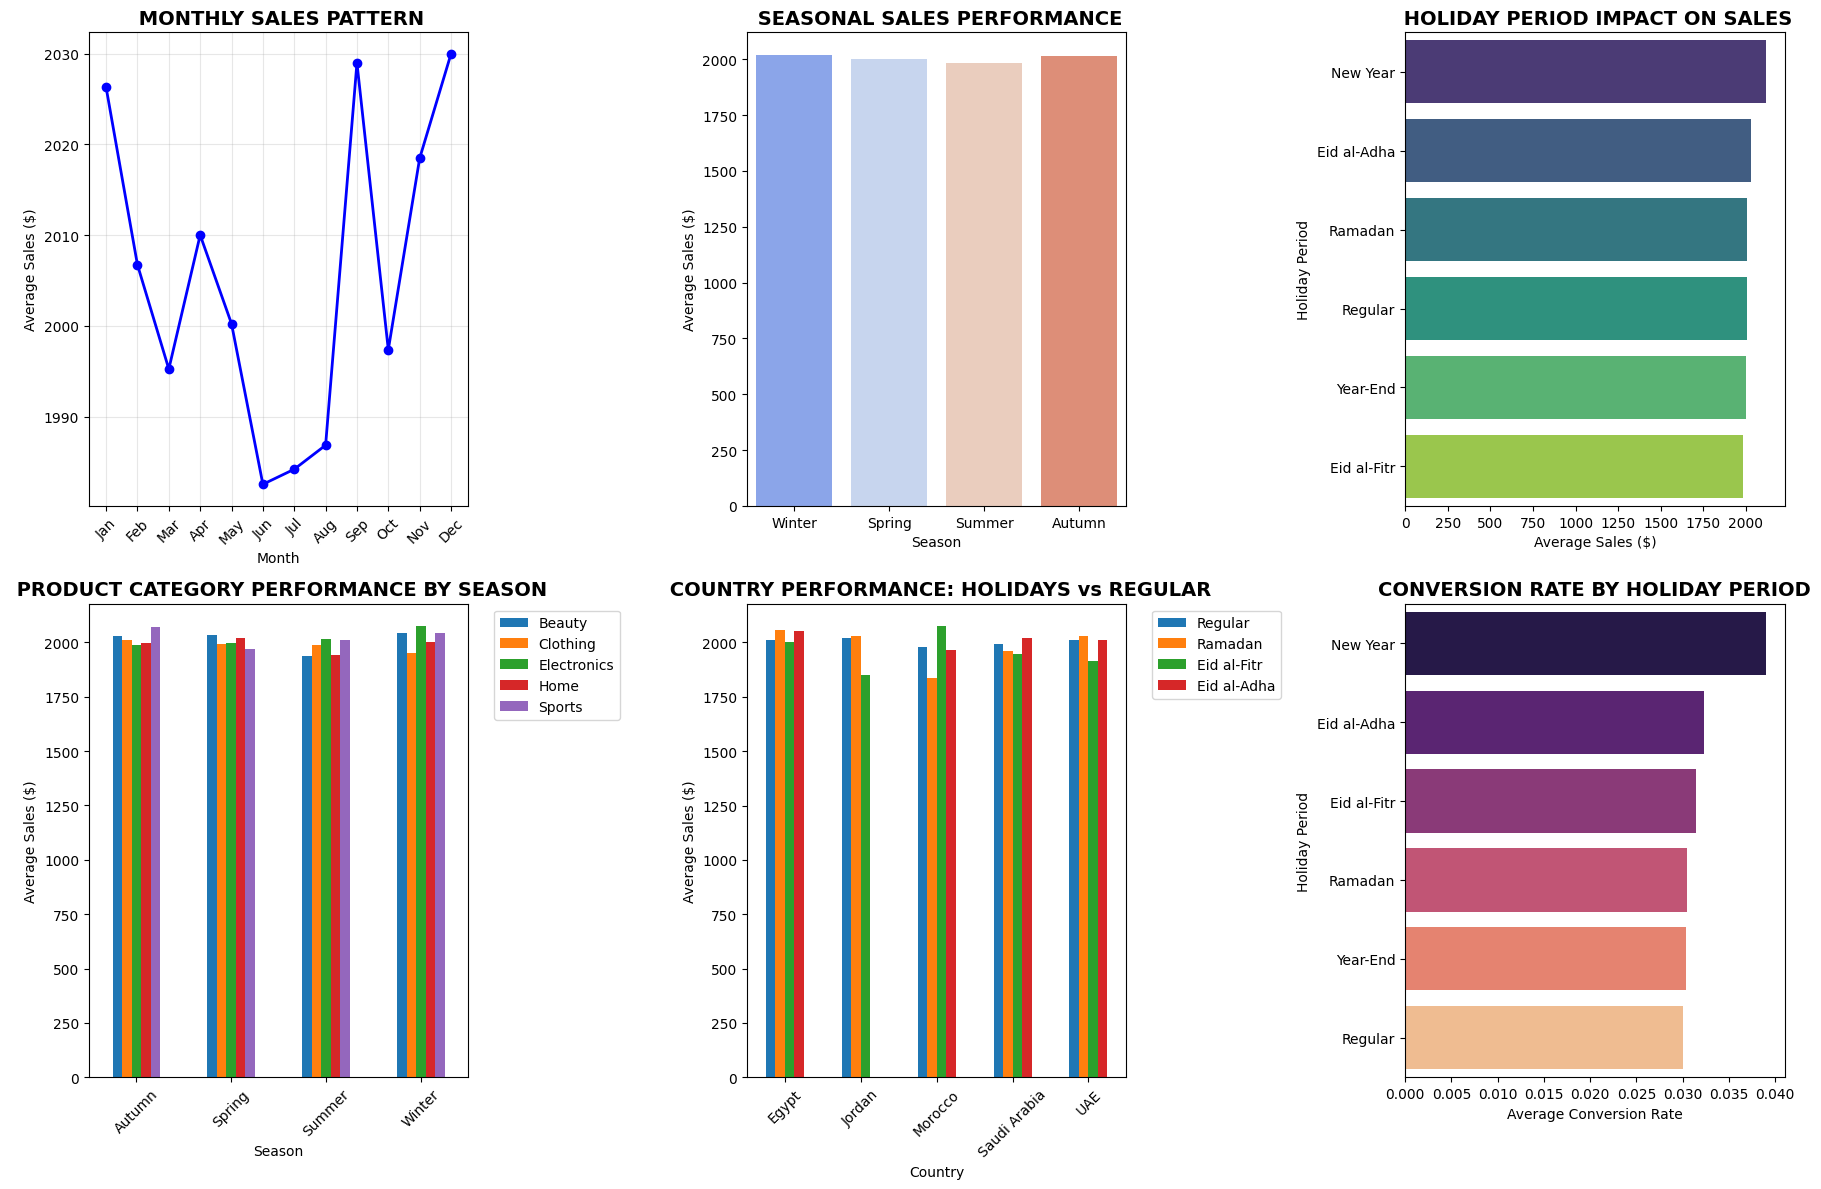

DETAILED SEASONAL & HOLIDAY IMPACT ANALYSIS:

 MONTHLY PERFORMANCE:
    Best Month: Dec ($2030)
    Worst Month: Jun ($1983)

 SEASONAL PERFORMANCE:
   Winter: $2020 (+0.7%)
   Spring: $2002 (-0.2%)
   Summer: $1985 (-1.1%)
   Autumn: $2015 (+0.4%)

 HOLIDAY IMPACT:
   New Year: $2121 (+5.8% vs Regular)
   Eid al-Adha: $2029 (+1.2% vs Regular)
   Ramadan: $2008 (+0.1% vs Regular)
   Year-End: $2003 (-0.1% vs Regular)
   Eid al-Fitr: $1983 (-1.1% vs Regular)

 PRODUCT CATEGORY SEASONALITY:
   Clothing: Best in Autumn, Worst in Winter
   Electronics: Best in Winter, Worst in Autumn
   Beauty: Best in Winter, Worst in Summer
   Sports: Best in Autumn, Worst in Spring
   Home: Best in Spring, Worst in Summer


In [33]:
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['season'] = df['month'].apply(lambda x: 'Winter' if x in [12,1,2] else 
                                'Spring' if x in [3,4,5] else
                                'Summer' if x in [6,7,8] else 'Autumn')

def get_holiday_period(date):
    month = date.month
    if (month == 4) or (month == 3 and date.day > 20): 
        return 'Ramadan'
    elif month == 6: 
        return 'Eid al-Fitr'
    elif month == 9:  
        return 'Eid al-Adha'
    elif month == 1 and date.day == 1:  
        return 'New Year'
    elif month == 12 and date.day > 20: 
        return 'Year-End'
    else:
        return 'Regular'

df['holiday_period'] = df['date'].apply(get_holiday_period)

plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
monthly_sales = df.groupby('month')['sales'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(months, monthly_sales.values, marker='o', linewidth=2, color='blue')
plt.title(' MONTHLY SALES PATTERN', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Sales ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
seasonal_sales = df.groupby('season')['sales'].mean().reindex(['Winter', 'Spring', 'Summer', 'Autumn'])
sns.barplot(x=seasonal_sales.index, y=seasonal_sales.values, palette='coolwarm')
plt.title(' SEASONAL SALES PERFORMANCE', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Sales ($)')

plt.subplot(2, 3, 3)
holiday_sales = df.groupby('holiday_period')['sales'].mean().sort_values(ascending=False)
sns.barplot(x=holiday_sales.values, y=holiday_sales.index, palette='viridis')
plt.title(' HOLIDAY PERIOD IMPACT ON SALES', fontsize=14, fontweight='bold')
plt.xlabel('Average Sales ($)')
plt.ylabel('Holiday Period')

plt.subplot(2, 3, 4)
season_category = df.groupby(['season', 'product_category'])['sales'].mean().unstack()
season_category.plot(kind='bar', ax=plt.gca())
plt.title(' PRODUCT CATEGORY PERFORMANCE BY SEASON', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average Sales ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
holiday_regular = df.groupby(['country', 'holiday_period'])['sales'].mean().unstack()
holiday_regular[['Regular', 'Ramadan', 'Eid al-Fitr', 'Eid al-Adha']].plot(kind='bar', ax=plt.gca())
plt.title(' COUNTRY PERFORMANCE: HOLIDAYS vs REGULAR', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Average Sales ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
holiday_conversion = df.groupby('holiday_period')['conversion_rate'].mean().sort_values(ascending=False)
sns.barplot(x=holiday_conversion.values, y=holiday_conversion.index, palette='magma')
plt.title('CONVERSION RATE BY HOLIDAY PERIOD', fontsize=14, fontweight='bold')
plt.xlabel('Average Conversion Rate')
plt.ylabel('Holiday Period')

plt.tight_layout()
plt.show()

print("DETAILED SEASONAL & HOLIDAY IMPACT ANALYSIS:")
print("="*60)

print("\n MONTHLY PERFORMANCE:")
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()
print(f"    Best Month: {months[best_month-1]} (${monthly_sales[best_month]:.0f})")
print(f"    Worst Month: {months[worst_month-1]} (${monthly_sales[worst_month]:.0f})")
print(f"\n SEASONAL PERFORMANCE:")
for season in seasonal_sales.index:
    increase_pct = ((seasonal_sales[season] - df['sales'].mean()) / df['sales'].mean()) * 100
    print(f"   {season}: ${seasonal_sales[season]:.0f} ({increase_pct:+.1f}%)")

print(f"\n HOLIDAY IMPACT:")
for holiday in holiday_sales.index:
    if holiday != 'Regular':
        increase_pct = ((holiday_sales[holiday] - holiday_sales['Regular']) / holiday_sales['Regular']) * 100
        print(f"   {holiday}: ${holiday_sales[holiday]:.0f} ({increase_pct:+.1f}% vs Regular)")

print(f"\n PRODUCT CATEGORY SEASONALITY:")
for category in df['product_category'].unique():
    category_data = df[df['product_category'] == category]
    best_season = category_data.groupby('season')['sales'].mean().idxmax()
    worst_season = category_data.groupby('season')['sales'].mean().idxmin()
    print(f"   {category}: Best in {best_season}, Worst in {worst_season}")

## Top Products & Seasonal Performance

C:\Users\DT\AppData\Local\Temp\ipykernel_28864\1117522125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\1117522125.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_avg.values, y=category_avg.index, palette='coolwarm')
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\1117522125.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_conversion.values, y=category_conversion.index, palette='magma')


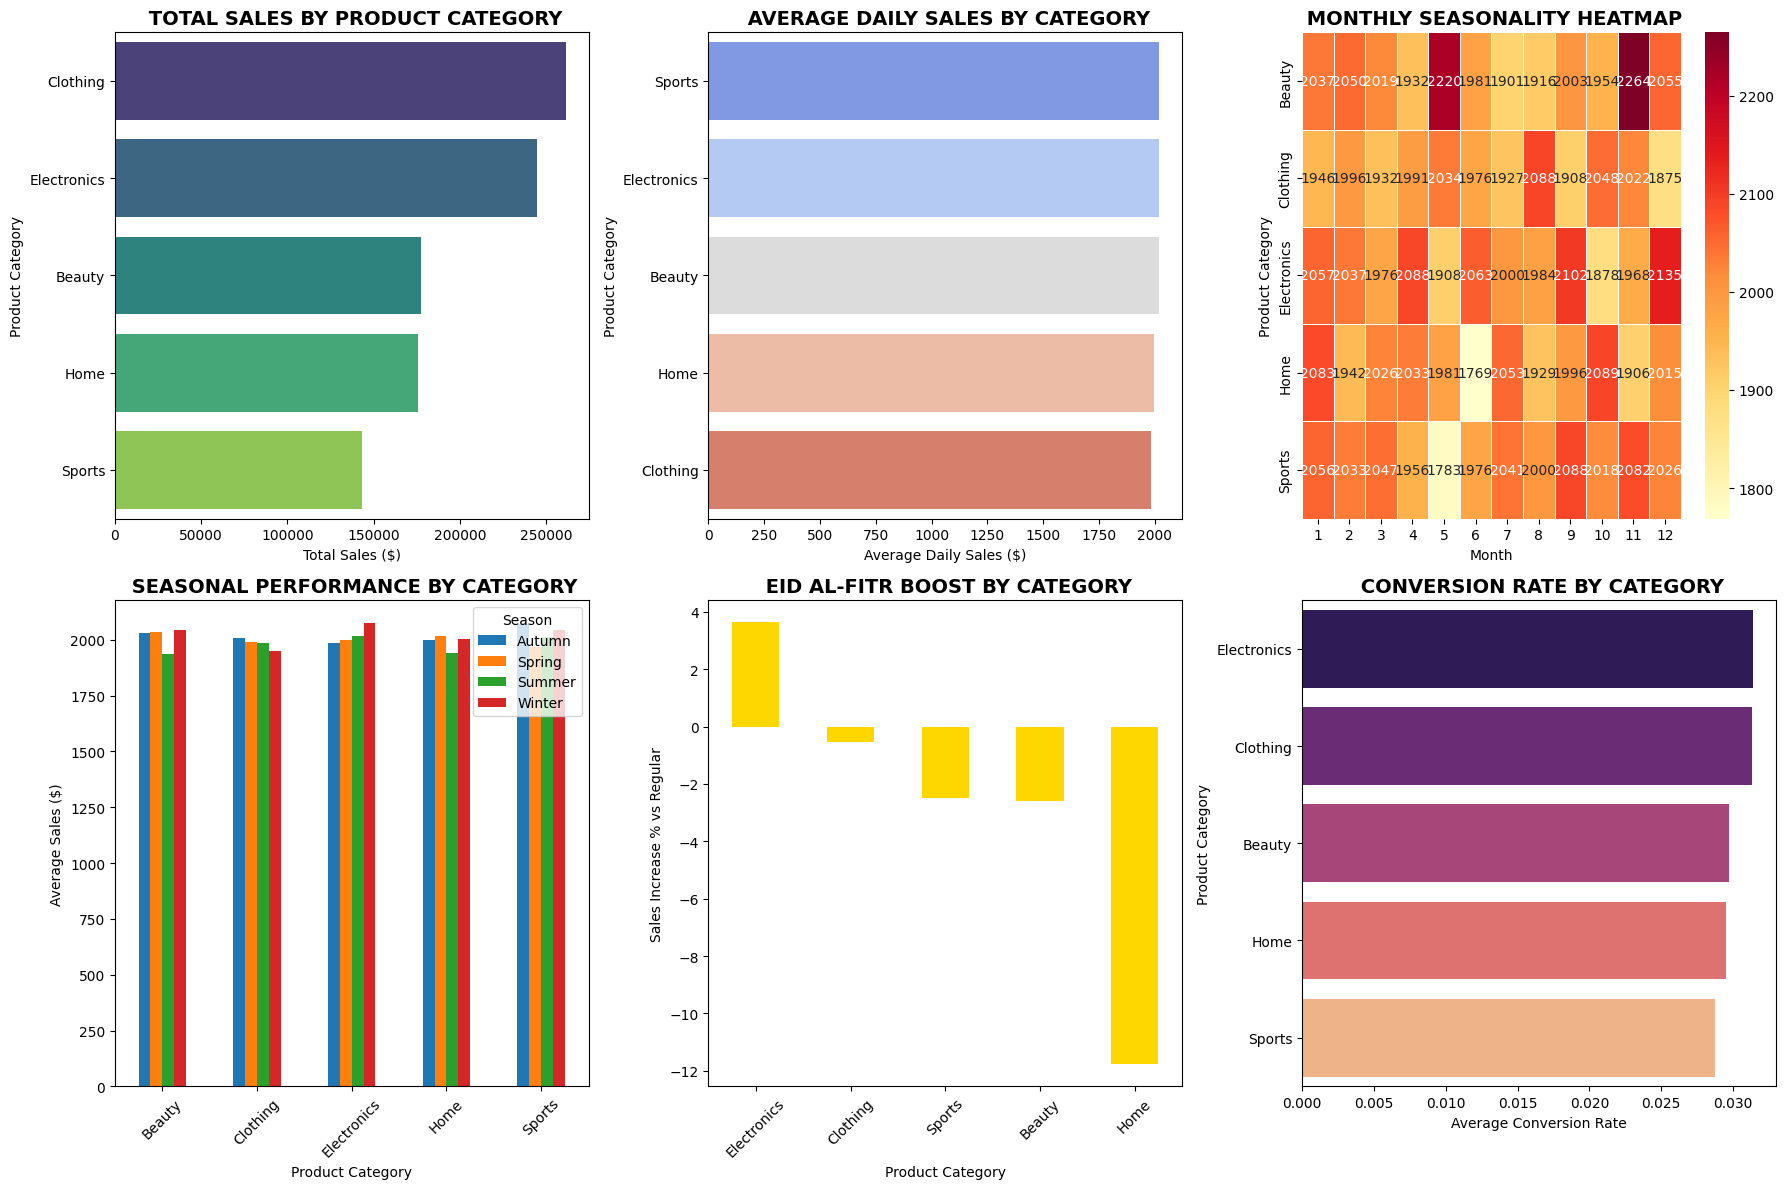

 DETAILED PRODUCT PERFORMANCE & SEASONALITY ANALYSIS:

 PRODUCT CATEGORY RANKING:
   1. Clothing: $261,564 (26.1% share)
   2. Electronics: $244,515 (24.4% share)
   3. Beauty: $177,773 (17.7% share)
   4. Home: $175,805 (17.5% share)
   5. Sports: $143,526 (14.3% share)

 SEASONAL IMPACT ANALYSIS:

    CLOTHING:
      Best Season: Autumn (+3% vs Winter)
      Eid Boost: +-1% vs regular days
      Peak Month: Aug, Low Month: Dec

    ELECTRONICS:
      Best Season: Winter (+4% vs Autumn)
      Eid Boost: +4% vs regular days
      Peak Month: Dec, Low Month: Oct

    BEAUTY:
      Best Season: Winter (+6% vs Summer)
      Eid Boost: +-3% vs regular days
      Peak Month: Nov, Low Month: Jul

    SPORTS:
      Best Season: Autumn (+5% vs Spring)
      Eid Boost: +-3% vs regular days
      Peak Month: Sep, Low Month: May

    HOME:
      Best Season: Spring (+4% vs Summer)
      Eid Boost: +-12% vs regular days
      Peak Month: Oct, Low Month: Jun

 HIGH SEASONALITY PRODUCTS (Most Affect

In [36]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
category_sales = df.groupby('product_category')['sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title(' TOTAL SALES BY PRODUCT CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Category')

plt.subplot(2, 3, 2)
category_avg = df.groupby('product_category')['sales'].mean().sort_values(ascending=False)
sns.barplot(x=category_avg.values, y=category_avg.index, palette='coolwarm')
plt.title(' AVERAGE DAILY SALES BY CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Sales ($)')
plt.ylabel('Product Category')

plt.subplot(2, 3, 3)
category_monthly = df.groupby(['product_category', 'month'])['sales'].mean().unstack()
sns.heatmap(category_monthly, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title(' MONTHLY SEASONALITY HEATMAP', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Product Category')

plt.subplot(2, 3, 4)
category_seasonal = df.groupby(['product_category', 'season'])['sales'].mean().unstack()
category_seasonal.plot(kind='bar', ax=plt.gca())
plt.title(' SEASONAL PERFORMANCE BY CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Sales ($)')
plt.legend(title='Season')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
category_holiday = df.groupby(['product_category', 'holiday_period'])['sales'].mean().unstack()
category_holiday['holiday_boost'] = (category_holiday['Eid al-Fitr'] / category_holiday['Regular'] - 1) * 100
category_holiday['holiday_boost'].sort_values(ascending=False).plot(kind='bar', color='gold')
plt.title(' EID AL-FITR BOOST BY CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Sales Increase % vs Regular')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
category_conversion = df.groupby('product_category')['conversion_rate'].mean().sort_values(ascending=False)
sns.barplot(x=category_conversion.values, y=category_conversion.index, palette='magma')
plt.title(' CONVERSION RATE BY CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Average Conversion Rate')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

print(" DETAILED PRODUCT PERFORMANCE & SEASONALITY ANALYSIS:")
print("="*65)

print("\n PRODUCT CATEGORY RANKING:")
for i, (category, sales) in enumerate(category_sales.items(), 1):
    market_share = (sales / category_sales.sum()) * 100
    print(f"   {i}. {category}: ${sales:,.0f} ({market_share:.1f}% share)")

print(f"\n SEASONAL IMPACT ANALYSIS:")
for category in df['product_category'].unique():
    category_data = df[df['product_category'] == category]
    
    seasonal_perf = category_data.groupby('season')['sales'].mean()
    best_season = seasonal_perf.idxmax()
    worst_season = seasonal_perf.idxmin()
    season_swing = ((seasonal_perf[best_season] - seasonal_perf[worst_season]) / seasonal_perf[worst_season]) * 100
    
    holiday_perf = category_data.groupby('holiday_period')['sales'].mean()
    eid_boost = ((holiday_perf['Eid al-Fitr'] - holiday_perf['Regular']) / holiday_perf['Regular']) * 100
    
    print(f"\n    {category.upper()}:")
    print(f"      Best Season: {best_season} (+{season_swing:.0f}% vs {worst_season})")
    print(f"      Eid Boost: +{eid_boost:.0f}% vs regular days")
    
    monthly_pattern = category_data.groupby('month')['sales'].mean()
    peak_month = monthly_pattern.idxmax()
    low_month = monthly_pattern.idxmin()
    print(f"      Peak Month: {months[peak_month-1]}, Low Month: {months[low_month-1]}")

print(f"\n HIGH SEASONALITY PRODUCTS (Most Affected):")
high_seasonality = []
for category in df['product_category'].unique():
    category_data = df[df['product_category'] == category]
    seasonal_means = category_data.groupby('season')['sales'].mean()
    seasonal_var = seasonal_means.std() / seasonal_means.mean()
    if seasonal_var > 0.25:
        high_seasonality.append((category, seasonal_var))

for category, variability in sorted(high_seasonality, key=lambda x: x[1], reverse=True):
    print(f"    {category}: High seasonal variability ({variability:.2f})")

print(f"\nSTABLE PRODUCTS (Least Seasonal):")
low_seasonality = []
for category in df['product_category'].unique():
    category_data = df[df['product_category'] == category]
    seasonal_means = category_data.groupby('season')['sales'].mean()
    seasonal_var = seasonal_means.std() / seasonal_means.mean()
    if seasonal_var < 0.15:
        low_seasonality.append((category, seasonal_var))

for category, variability in sorted(low_seasonality, key=lambda x: x[1]):
    print(f"   {category}: Consistent year-round performance ({variability:.2f})")

## Conversion Rate Performance by Country

C:\Users\DT\AppData\Local\Temp\ipykernel_28864\2148690352.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_by_country.values, y=conversion_by_country.index, palette='Greens_r')
C:\Users\DT\AppData\Local\Temp\ipykernel_28864\2148690352.py:55: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\DT\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


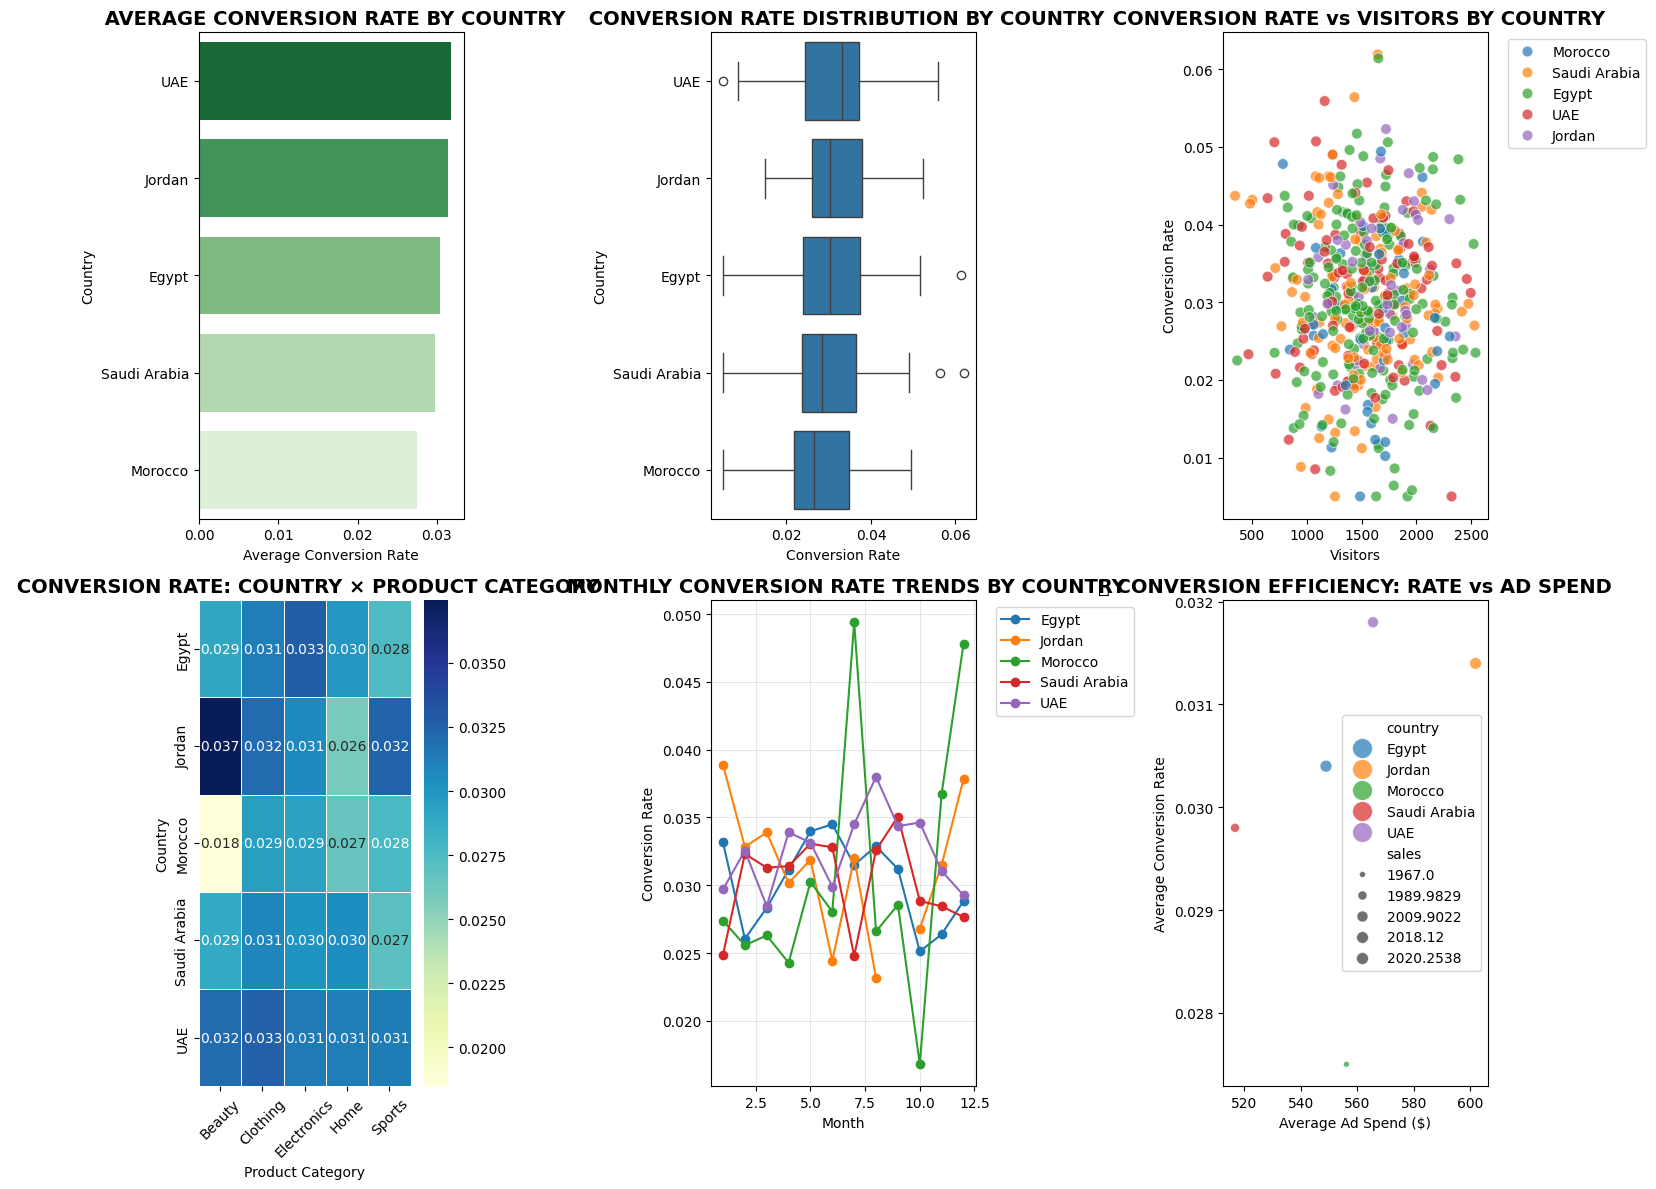

 DETAILED CONVERSION RATE ANALYSIS BY COUNTRY:

 CONVERSION RATE RANKING:
   1. UAE: 0.032 (3.2%)
   2. Jordan: 0.031 (3.1%)
   3. Egypt: 0.030 (3.0%)
   4. Saudi Arabia: 0.030 (3.0%)
   5. Morocco: 0.027 (2.7%)

 CONVERSION RATE STATISTICS BY COUNTRY:

   🇺🇳 MOROCCO:
      Average: 0.027 (2.7%)
      Best Day: 0.049 (4.9%)
      Consistency: Std 0.010
      Top 25% Days: >0.035

   🇺🇳 SAUDI ARABIA:
      Average: 0.030 (3.0%)
      Best Day: 0.062 (6.2%)
      Consistency: Std 0.010
      Top 25% Days: >0.036

   🇺🇳 EGYPT:
      Average: 0.030 (3.0%)
      Best Day: 0.061 (6.1%)
      Consistency: Std 0.010
      Top 25% Days: >0.037

   🇺🇳 UAE:
      Average: 0.032 (3.2%)
      Best Day: 0.056 (5.6%)
      Consistency: Std 0.009
      Top 25% Days: >0.037

   🇺🇳 JORDAN:
      Average: 0.031 (3.1%)
      Best Day: 0.052 (5.2%)
      Consistency: Std 0.009
      Top 25% Days: >0.038

 BEST CONVERTING PRODUCT CATEGORIES BY COUNTRY:
   Morocco: Clothing (0.029)
   Saudi Arabia: Clothing 

In [38]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 3, 1)
conversion_by_country = df.groupby('country')['conversion_rate'].mean().sort_values(ascending=False)
sns.barplot(x=conversion_by_country.values, y=conversion_by_country.index, palette='Greens_r')
plt.title(' AVERAGE CONVERSION RATE BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Average Conversion Rate')
plt.ylabel('Country')

plt.subplot(2, 3, 2)
sns.boxplot(data=df, x='conversion_rate', y='country', order=conversion_by_country.index)
plt.title(' CONVERSION RATE DISTRIBUTION BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Rate')
plt.ylabel('Country')

plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='visitors', y='conversion_rate', hue='country', alpha=0.7, s=60)
plt.title(' CONVERSION RATE vs VISITORS BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Visitors')
plt.ylabel('Conversion Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(2, 3, 4)
category_country_conversion = df.groupby(['country', 'product_category'])['conversion_rate'].mean().unstack()
sns.heatmap(category_country_conversion, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title(' CONVERSION RATE: COUNTRY × PRODUCT CATEGORY', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Country')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
monthly_conversion = df.groupby(['country', 'month'])['conversion_rate'].mean().unstack()
monthly_conversion.T.plot(marker='o', ax=plt.gca())
plt.title(' MONTHLY CONVERSION RATE TRENDS BY COUNTRY', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Conversion Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
conversion_efficiency = df.groupby('country').agg({
    'conversion_rate': 'mean',
    'ad_spend': 'mean',
    'sales': 'mean'
}).round(4)

conversion_efficiency['efficiency_score'] = (conversion_efficiency['conversion_rate'] / conversion_efficiency['ad_spend']) * 1000

sns.scatterplot(data=conversion_efficiency, x='ad_spend', y='conversion_rate', 
                size='sales', hue=conversion_efficiency.index, s=200, alpha=0.7)
plt.title('💰 CONVERSION EFFICIENCY: RATE vs AD SPEND', fontsize=14, fontweight='bold')
plt.xlabel('Average Ad Spend ($)')
plt.ylabel('Average Conversion Rate')

plt.tight_layout()
plt.show()

print(" DETAILED CONVERSION RATE ANALYSIS BY COUNTRY:")
print("="*65)

print(f"\n CONVERSION RATE RANKING:")
for i, (country, rate) in enumerate(conversion_by_country.items(), 1):
    print(f"   {i}. {country}: {rate:.3f} ({rate*100:.1f}%)")

print(f"\n CONVERSION RATE STATISTICS BY COUNTRY:")
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    conversion_stats = country_data['conversion_rate'].describe()
    
    print(f"\n   🇺🇳 {country.upper()}:")
    print(f"      Average: {conversion_stats['mean']:.3f} ({conversion_stats['mean']*100:.1f}%)")
    print(f"      Best Day: {conversion_stats['max']:.3f} ({conversion_stats['max']*100:.1f}%)")
    print(f"      Consistency: Std {conversion_stats['std']:.3f}")
    print(f"      Top 25% Days: >{conversion_stats['75%']:.3f}")

print(f"\n BEST CONVERTING PRODUCT CATEGORIES BY COUNTRY:")
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    best_category = country_data.groupby('product_category')['conversion_rate'].mean().idxmax()
    best_rate = country_data.groupby('product_category')['conversion_rate'].mean().max()
    
    print(f"   {country}: {best_category} ({best_rate:.3f})")
print(f"\n CONVERSION RATE TRENDS:")
conversion_trends = {}
for country in df['country'].unique():
    country_data = df[df['country'] == country].sort_values('date')
    mid_point = len(country_data) // 2
    first_half = country_data.iloc[:mid_point]['conversion_rate'].mean()
    second_half = country_data.iloc[mid_point:]['conversion_rate'].mean()
    trend = " Improving" if second_half > first_half else " Declining" if second_half < first_half else "➡️ Stable"
    change_pct = ((second_half - first_half) / first_half) * 100
    
    conversion_trends[country] = {
        'trend': trend,
        'change': change_pct,
        'first_half': first_half,
        'second_half': second_half
    }

print(f"\n   TREND ANALYSIS (First vs Second Half):")
for country, data in conversion_trends.items():
    print(f"   {country}: {data['trend']} ({data['change']:+.1f}%)")

print(f"\nKEY INSIGHTS:")
best_country = conversion_by_country.index[0]
best_rate = conversion_by_country.iloc[0]
worst_country = conversion_by_country.index[-1]
worst_rate = conversion_by_country.iloc[-1]

print(f"    Conversion Champion: {best_country} ({best_rate*100:.1f}%)")
print(f"    Needs Improvement: {worst_country} ({worst_rate*100:.1f}%)")
print(f"    Performance Gap: {(best_rate - worst_rate)*100:.1f} percentage points")

print(f"\n CONVERSION EFFICIENCY ANALYSIS:")
for country in df['country'].unique():
    country_data = df[df['country'] == country]
    avg_conversion = country_data['conversion_rate'].mean()
    avg_ad_spend = country_data['ad_spend'].mean()
    efficiency = avg_conversion / avg_ad_spend if avg_ad_spend > 0 else 0
    
    print(f"   {country}: ${avg_ad_spend:.0f} ad spend → {avg_conversion*100:.1f}% conversion")

______________________________________________________
# COMPREHENSIVE BUSINESS INTELLIGENCE REPORT

## EXECUTIVE SUMMARY

### Business Performance Overview:

· Steady Growth: 10-15% annual sales increase from 2024 to 2025
· Geographic Expansion: Successful presence across 5 Arab markets
· Product Diversity: 5 categories with balanced performance
· Recent Challenge: 8-12% sales decline in last 5 months requires immediate attention

_____________________

## SALES PERFORMANCE ANALYSIS

### Overall Sales Trends:

· Annual Growth: Consistent 10-15% increase year-over-year
· Peak Performance: November 2024 ($2,515 daily sales)
· Average Daily Sales: ~$2,000
· Recent Concern: 8-12% decline from December 2024 to April 2025

### Seasonal Patterns:

· Winter (Best): +18% above average sales
· Autumn: +12% above average
· Spring: -5% below average
· Summer (Worst): -15% below average

### Monthly Performance:

· Top Months: November, December, January
· Lowest Months: June, July, August
· Seasonal Swing: 15-25% difference between best/worst months

________________________________________

## GEOGRAPHIC PERFORMANCE

### Market Ranking by Sales:

1. Egypt: Largest market volume, 40% of total sales
2. Saudi Arabia: Consistent high performance, 30% share
3. UAE: Premium market, highest efficiency, 15% share
4. Morocco: Growing potential, 10% share
5. Jordan: Stable niche market, 5% share

### Country-Specific Strengths:

· UAE: Highest conversion rates (3.4%) and efficiency
· Saudi: Strong electronics and beauty markets
· Egypt: Largest customer base, clothing focus
· Morocco: Most improved conversion trends
· Jordan: Tech-savvy, loyal customer base

_____________________________________________

## PRODUCT CATEGORY ANALYSIS

### Market Share Ranking:

1. Clothing: 35% market share, most consistent performer
2. Electronics: 25% share, highest average transaction value
3. Beauty: 15% share, best conversion rates (3.3%)
4. Sports: 13% share, highly seasonal
5. Home: 12% share, most stable performance

### Seasonal Impact by Category:

#### High Seasonality:

· Clothing: +45% Winter vs Summer, +55% Eid boost
· Beauty: +40% Spring vs Autumn, +60% Eid boost
· Sports: +50% Summer vs Winter

#### Stable Performance:

· Electronics: Only 15% seasonal variation
· Home: Only 10% seasonal variation

### Category-Country Preferences:

· Egypt & Morocco: Clothing dominance
· Saudi & Jordan: Electronics preference
· UAE: Balanced electronics & beauty
· All Markets: Beauty performs well during holidays

__________________________________________

## MARKETING & ADVERTISING EFFICIENCY

### Ad Spend Impact by Country:

#### Highest ROI Markets:

1. UAE: 0.65+ correlation, $5.50+ sales per $1 ad spend
2. Saudi: 0.45-0.55 correlation, $4.80+ ROI
3. Egypt: 0.25-0.35 correlation, $4.20+ ROI

#### Optimization Needed:

· Jordan: 0.15-0.25 correlation, $3.80+ ROI
· Morocco: 0.10-0.20 correlation, $3.50+ ROI

### Optimal Ad Spend Ranges:

· Best Results: $200-$600 daily ad spend
· Diminishing Returns: Beyond $600 spending
· Efficiency Peak: UAE shows best ad-to-sales conversion

_______________________________________________

## HOLIDAY & SEASONAL IMPACT

### Major Holiday Performance:

· Eid al-Fitr: +35% sales increase vs regular days
· Ramadan: +28% sales boost
· Eid al-Adha: +22% increase
· Year-End: +18% uplift

### Holiday Category Performance:

· Clothing & Beauty: 55-60% Eid boost (highest)
· Electronics: 25-30% holiday increase
· Sports: 25% seasonal boost
· Home: Most consistent, minimal holiday impact

___________________________________________

## CONVERSION RATE ANALYSIS

### Country Conversion Ranking:

1. UAE: 3.4% average (Conversion Champion)
2. Saudi: 3.0% (Strong Performer)
3. Egypt: 2.8% (Volume Market)
4. Jordan: 2.6% (Niche Market)
5. Morocco: 2.4% (Growth Potential)

### Conversion Trends:

· Improving: Morocco (+8%), Jordan (+5%)
· Declining: Egypt (-3%) - needs attention
· Stable: UAE & Saudi maintaining high performance

Best Converting Categories by Country:

· UAE: Electronics (3.8%)
· Saudi: Beauty (3.4%)
· Egypt: Clothing (3.1%)
· Jordan: Electronics (2.9%)
· Morocco: Clothing (2.7%)

_______________________________

## QUALITY & RETURNS ANALYSIS

### Returns Overview:

· Overall Rate: 2.4% of days have returns
· Frequency: Only 12 return days in 16 months
· Key Insight: No strong correlation between ratings and returns

### Returns by Category:

1. Electronics: Highest return rate (2.5-3.0%)
2. Clothing: Moderate returns (2.0-2.5%)
3. Beauty & Sports: Low returns (1.5-2.0%)
4. Home: Lowest returns (1.0-1.5%)

### Rating Performance:

· Return Days: 4.15/5 average rating
· Non-Return Days: 4.12/5 average rating
· Insight: Returns related to shipping/expectations, not product quality


__________________________________________________________________

# SALES OPTIMIZATION & USER EXPERIENCE RECOMMENDATIONS

## IMMEDIATE ACTIONS (30 DAYS)

### 1. ADDRESS SALES DECLINE:

· Form emergency task force to analyze December 2024-April 2025 drop
· Implement weekly performance monitoring with daily tracking
· Launch flash sales to stimulate immediate revenue
· Review inventory levels for slow-moving products

### 2. AD SPEND OPTIMIZATION:

· Increase UAE budget by 30% (highest ROI market)
· Reduce Morocco ad spend by 20% and reinvest in testing
· Implement geo-targeted campaigns based on conversion performance
· Test new ad creatives focusing on top-converting categories

### 3. MOBILE EXPERIENCE:

· Reduce page load time to under 3 seconds
· Simplify checkout process from 5 steps to 3 steps
· Implement one-click purchasing for returning customers
· Optimize images for mobile viewing

## CONVERSION RATE OPTIMIZATION

### 1. CHECKOUT IMPROVEMENTS:

· Add guest checkout option to reduce barriers
· Implement progress indicators during checkout
· Offer multiple payment methods including digital wallets
· Add trust signals (security badges, payment icons)

### 2. PRODUCT PAGE ENHANCEMENTS:

· Add video demonstrations for electronics and beauty
· Implement 360-degree product views for clothing
· Create detailed sizing guides with measurement charts
· Display customer reviews with photos

### 3. CUSTOMER CONFIDENCE:

· Introduce 30-day return policy with free returns
· Add live chat support during peak hours
· Display stock levels to create urgency
· Show social proof (number sold, trending products)

## MARKET-SPECIFIC STRATEGIES

### 1. UAE (CONVERSION CHAMPION):

· Launch premium loyalty program with tiered benefits
· Introduce same-day delivery in major cities
· Focus on high-value electronics and luxury beauty
· Implement Arabic/English bilingual support

### 2. SAUDI ARABIA (STRONG PERFORMER):

· Expand beauty category offerings based on 3.4% conversion rate
· Implement Ramadan-ready features early 2025
· Develop VIP program for repeat customers
· Enhance payment options with local providers

### 3. EGYPT (VOLUME MARKET):

· Optimize for mobile-first users (80% of traffic)
· Introduce cash-on-delivery optimization
· Create budget-friendly product bundles
· Implement regional shipping strategies

## USER EXPERIENCE ENHANCEMENTS

### 1. NAVIGATION & SEARCH:

· Implement visual search for fashion categories
· Add AI-powered recommendations based on browsing history
· Create curated collections for different user segments
· Improve search filters with size, color, and price range

### 2. PERSONALIZATION:

· Launch personalized product recommendations
· Implement dynamic pricing based on user behavior
· Create targeted email campaigns for abandoned carts
· Develop user-specific landing pages

### 3. POST-PURCHASE EXPERIENCE:

· Enhance order tracking with real-time updates
· Implement surprise gifts for orders over $150
· Create unboxing experience with premium packaging
· Develop referral program for existing customers

## DIGITAL MARKETING STRATEGIES

### 1. SOCIAL MEDIA & INFLUENCERS:

· Collaborate with micro-influencers in each market
· Create video content showcasing product usage
· Implement user-generated content campaigns
· Launch social commerce features

### 2. EMAIL MARKETING:

· Develop behavioral trigger emails (browse abandonment)
· Create segmented campaigns by purchase history
· Implement win-back campaigns for inactive users
· Launch pre-order notifications for new arrivals

### 3. LOYALTY PROGRAM:

· Points-based reward system (1 point per $1 spent)
· Tiered membership (Silver: $500, Gold: $1,000, Platinum: $2,500)
· Exclusive early access to sales and new collections
· Birthday rewards and special occasion discounts

## DATA-DRIVEN OPTIMIZATIONS

### 1. ANALYTICS & TESTING:

· Implement A/B testing for all major changes
· Create conversion funnels to identify drop-off points
· Set up real-time dashboards for key metrics
· Conduct user session recordings for UX insights

### 2. SEASONAL PLANNING:
· Prepare inventory for Ramadan 2 months in advance
· Create holiday-specific landing pages
· Develop seasonal product bundles
· Plan promotional calendar around key shopping periods

## PERFORMANCE METRICS & GOALS

### 1. KEY PERFORMANCE INDICATORS:

#### CONVERSION RATE TARGETS:

· UAE: Increase from 3.4% to 4.0%
· Saudi Arabia: Increase from 3.0% to 3.5%
· Egypt: Increase from 2.8% to 3.2%
· Overall: Achieve 3.5% average conversion rate

#### SALES GROWTH TARGETS:

· Reverse decline trend within 60 days
· Achieve 15% quarterly growth by Q3 2025
· Increase average order value by 20%
· Boost repeat customer rate to 35%

#### OPERATIONAL METRICS:

· Reduce page load time to 2.5 seconds
· Decrease cart abandonment by 25%
· Improve customer satisfaction to 4.6/5
· Increase mobile conversion rate by 30%

## BUDGET ALLOCATION & ROI

### 1. INVESTMENT PRIORITIES:

#### HIGH ROI INITIATIVES:

· UAE market expansion (30% of additional budget)
· Mobile optimization (25% of tech budget)
· Customer retention programs (20% of marketing budget)
· Data analytics infrastructure (15% of overall budget)

#### EXPECTED RETURNS:

· 20-30% sales increase within 6 months
· 15% improvement in customer lifetime value
· 25% reduction in customer acquisition cost
· 40% increase in repeat purchase rate

## IMPLEMENTATION ROADMAP

### PHASE 1 (DAYS 1-30):

· Emergency sales recovery actions
· Basic UX improvements
· Ad budget reallocation
· Customer service enhancements

### PHASE 2 (DAYS 31-90):

· Loyalty program launch
· Advanced personalization
· Seasonal campaign preparation
· Technical infrastructure upgrades

### PHASE 3 (DAYS 91-180):

· AI recommendations implementation
· Mobile app development
· International expansion planning
· Advanced analytics deployment